In [1]:
import pandas as pd
import numpy as np

speech = pd.read_csv("../data/metadata/speech_features.csv")

print(speech.shape)

(10322, 51)


In [2]:
feature_columns = [
    "pitch_mean",
    "pitch_median",
    "pitch_min",
    "pitch_max",
    "pitch_std",
    "pitch_range",

    "energy_mean",
    "energy_std",
    "energy_min",
    "energy_max",
    "energy_range",

    "zcr_mean",
    "zcr_std",
    "zcr_min",
    "zcr_max",

    "jitter",
    "shimmer"
]

feature_columns += [
    f"mfcc_{i}_{stat}"
    for i in range(1, 14)
    for stat in ["mean", "std"]
]

X = speech[feature_columns].copy()
y = speech["emotion"].copy()

print("X:", X.shape)
print("y:", y.shape)

X: (10322, 43)
y: (10322,)


In [3]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns
)

print("Missing values:", X.isna().sum().sum())

Missing values: 0


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing :", X_test.shape)

Training: (8257, 43)
Testing : (2065, 43)


In [5]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=300, n_jobs=-1,
                       random_state=42)

In [6]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(
    y_test,
    y_pred,
    average="macro"
)

print("Accuracy:", accuracy)
print("Macro F1:", macro_f1)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred
    )
)

Accuracy: 0.6309927360774819
Macro F1: 0.6871745408249592

Classification Report:
              precision    recall  f1-score   support

       angry       0.69      0.81      0.74       331
        calm       0.93      0.97      0.95        77
     disgust       0.58      0.49      0.53       331
     fearful       0.70      0.42      0.52       331
       happy       0.58      0.60      0.59       331
     neutral       0.48      0.59      0.53       256
         sad       0.61      0.70      0.65       331
   surprised       0.95      1.00      0.97        77

    accuracy                           0.63      2065
   macro avg       0.69      0.70      0.69      2065
weighted avg       0.64      0.63      0.63      2065



<Figure size 900x700 with 0 Axes>

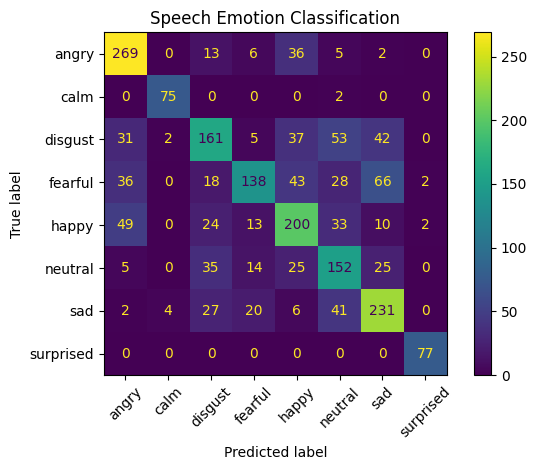

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(9, 7))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    xticks_rotation=45
)

plt.title("Speech Emotion Classification")
plt.tight_layout()

plt.savefig(
    "../outputs/figures/speech_emotion_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [8]:
shared_emotions = [
    "angry",
    "disgust",
    "fearful",
    "happy",
    "neutral",
    "sad"
]

cross_dataset = speech[
    speech["emotion"].isin(shared_emotions)
].copy()

In [9]:
crema = cross_dataset[
    cross_dataset["dataset"] == "CREMA-D"
]

ravdess = cross_dataset[
    cross_dataset["dataset"] == "RAVDESS"
]

In [15]:
X_train = crema[feature_columns]
y_train = crema["emotion"]

X_test = ravdess[feature_columns]
y_test = ravdess["emotion"]
imputer = SimpleImputer(strategy="median")

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)
model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print(
    "Accuracy:",
    accuracy_score(y_test, y_pred)
)

print(
    "Macro F1:",
    f1_score(
        y_test,
        y_pred,
        average="macro"
    )
)

              precision    recall  f1-score   support

       angry       0.73      0.41      0.53       384
     disgust       0.25      0.81      0.38       384
     fearful       0.48      0.06      0.11       384
       happy       0.26      0.34      0.29       384
     neutral       0.07      0.01      0.02       192
         sad       0.38      0.06      0.11       384

    accuracy                           0.31      2112
   macro avg       0.36      0.28      0.24      2112
weighted avg       0.39      0.31      0.26      2112

Accuracy: 0.3077651515151515
Macro F1: 0.2396275482823271


In [16]:
X_train = ravdess[feature_columns]
y_train = ravdess["emotion"]

X_test = crema[feature_columns]
y_test = crema["emotion"]
imputer = SimpleImputer(strategy="median")

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)
model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print(
    "Accuracy:",
    accuracy_score(y_test, y_pred)
)

print(
    "Macro F1:",
    f1_score(
        y_test,
        y_pred,
        average="macro"
    )
)

              precision    recall  f1-score   support

       angry       0.70      0.49      0.58      1271
     disgust       0.49      0.02      0.05      1271
     fearful       0.18      0.93      0.31      1271
       happy       0.21      0.01      0.02      1271
     neutral       0.25      0.00      0.00      1087
         sad       0.63      0.02      0.04      1271

    accuracy                           0.25      7442
   macro avg       0.41      0.25      0.17      7442
weighted avg       0.42      0.25      0.17      7442

Accuracy: 0.25194840096748183
Macro F1: 0.16599741706186652


In [17]:
comparison_features = [
    "pitch_mean",
    "pitch_std",
    "energy_mean",
    "energy_std",
    "zcr_mean",
    "zcr_std",
    "jitter",
    "shimmer"
]

for feature in comparison_features:
    print(f"\n{feature}")

    print(
        "CREMA-D:",
        speech.loc[
            speech["dataset"] == "CREMA-D",
            feature
        ].mean()
    )

    print(
        "RAVDESS:",
        speech.loc[
            speech["dataset"] == "RAVDESS",
            feature
        ].mean()
    )


pitch_mean
CREMA-D: 143.69956144841888
RAVDESS: 151.5636414104038

pitch_std
CREMA-D: 61.873097231361825
RAVDESS: 79.03491820361879

energy_mean
CREMA-D: 0.02697875470060548
RAVDESS: 0.010130963264358141

energy_std
CREMA-D: 0.02787863410223496
RAVDESS: 0.014719554242603562

zcr_mean
CREMA-D: 0.08389618252052376
RAVDESS: 0.26258797316501536

zcr_std
CREMA-D: 0.06598747633717944
RAVDESS: 0.21062782593588864

jitter
CREMA-D: 0.03581972021690287
RAVDESS: 0.025221092960446462

shimmer
CREMA-D: 0.19659522183316705
RAVDESS: 0.1234448829600189


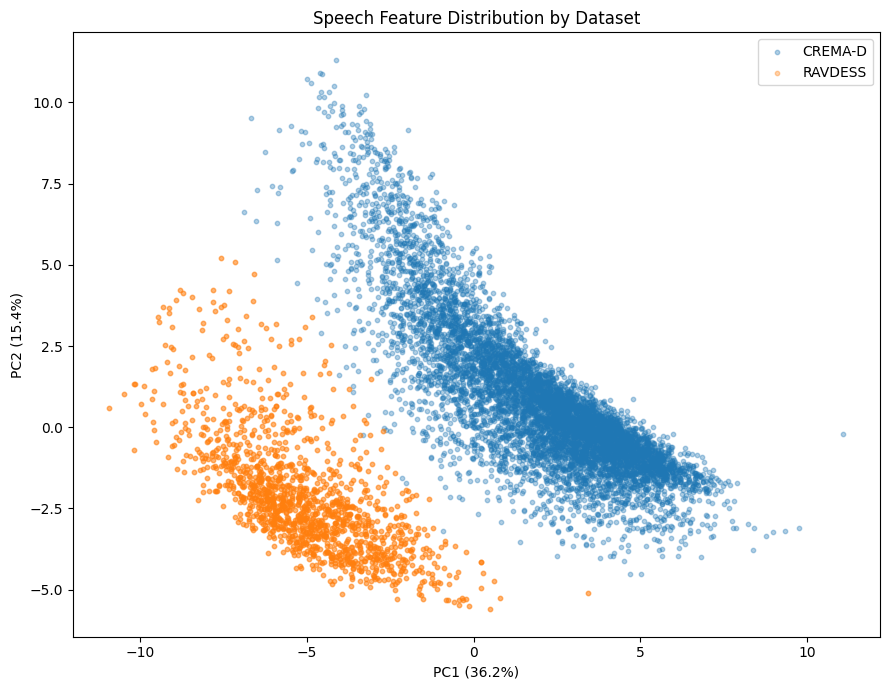

In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

X_domain = speech[feature_columns].copy()

X_domain = SimpleImputer(
    strategy="median"
).fit_transform(X_domain)

X_domain = StandardScaler().fit_transform(X_domain)

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_domain)

plt.figure(figsize=(9, 7))

for dataset in ["CREMA-D", "RAVDESS"]:
    mask = speech["dataset"].values == dataset

    plt.scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        label=dataset,
        alpha=0.35,
        s=10
    )

plt.xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)"
)

plt.ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)"
)

plt.title("Speech Feature Distribution by Dataset")
plt.legend()
plt.tight_layout()

plt.savefig(
    "../outputs/figures/speech_dataset_pca.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X = speech[feature_columns].copy()
X = SimpleImputer(strategy="median").fit_transform(X)

y = speech["dataset"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

domain_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

domain_model.fit(X_train, y_train)

pred = domain_model.predict(X_test)

print("Dataset classification accuracy:")
print(accuracy_score(y_test, pred))

Dataset classification accuracy:
1.0
